<a href="https://colab.research.google.com/github/santhosh1982/Youtube-Pytorch-Tutorial/blob/main/Neural_Network_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class Model(nn.Module):
    def __init__(self,in_features=4,h1=8,h2=9,out_features=3):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(in_features,h1)
        self.fc2 = nn.Linear(h1,h2)
        self.out = nn.Linear(h2,out_features)

    def forward(self, x):
      x = F.relu(self.fc1(x))
      x = F.relu(self.fc2(x))
      x = self.out(x)

      return x

torch.manual_seed(41)
model = Model(4,8,9,3)

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

In [4]:
url = 'https://gist.github.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
df = pd.read_csv(url)
df.tail()

,sepal.length,sepal.width,petal.length,petal.width,variety
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


In [5]:
df['variety'] = df['variety'].replace('Setosa', 0.0)
df['variety'] = df['variety'].replace('Versicolor', 1.0)
df['variety'] = df['variety'].replace('Virginica', 2.0)
df['variety']

/tmp/ipykernel_9077/4136942919.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['variety'] = df['variety'].replace('Virginica', 2.0)


,variety
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
145,2.0
146,2.0
147,2.0
148,2.0


In [6]:
X = df.drop('variety',axis=1)
y = df['variety']

In [7]:
X = X.values
y = y.values

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train,y_train,X_test,y_test = train_test_split(X,y,test_size=0.2, random_state=41)

In [10]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [11]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

In [13]:
epochs = 100
losses = []
for i in range(epochs):
  y_pred = model.forward(X_train)
  loss = criterion(y_pred, X_test.long()) # Corrected: using X_test (actual training labels) and casting to LongTensor
  losses.append(loss.detach().numpy())

  if i%10 == 0:
    print(f'Epochs {i}, Loss: {loss}')

  model.zero_grad()
  loss.backward()
  optimizer.step()

Epochs 0, Loss: 1.125203251838684
Epochs 10, Loss: 1.0097211599349976
Epochs 20, Loss: 0.8162348866462708
Epochs 30, Loss: 0.585993230342865
Epochs 40, Loss: 0.4003390073776245
Epochs 50, Loss: 0.2679471969604492
Epochs 60, Loss: 0.1796349734067917
Epochs 70, Loss: 0.12165623158216476
Epochs 80, Loss: 0.0860651433467865
Epochs 90, Loss: 0.06522615998983383


<Figure size 640x480 with 0 Axes>

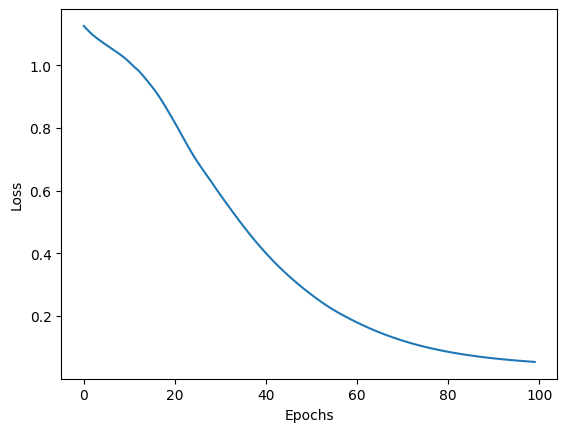

<Figure size 640x480 with 0 Axes>

In [14]:
plt.plot(range(epochs),losses)
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.figure()

In [18]:
with torch.no_grad():
  y_eval = model.forward(y_train.float()) # Corrected input: using y_train (actual test features) and casting to float
  loss = criterion(y_eval,y_test)

In [19]:
loss

tensor(0.3539)

In [24]:
correct = 0

with torch.no_grad():
  for i,data in enumerate(y_train):
     y_val = model.forward(data.float())

     print(f'{i+1}) \t {str(y_val)} \t {y_val.argmax().item()} \t {y_test[i]}')

     if y_val.argmax().item() == y_test[i]:
       correct += 1
print(f'Correct: {correct}')

1) 	 tensor([-4.9474,  4.7854,  4.5649]) 	 1 	 2
2) 	 tensor([-7.1587,  3.8698,  9.3673]) 	 2 	 2
3) 	 tensor([-7.6984,  4.6835,  9.4243]) 	 2 	 2
4) 	 tensor([-2.3581,  4.3466,  0.7346]) 	 1 	 1
5) 	 tensor([-6.2790,  4.5462,  7.1144]) 	 2 	 2
6) 	 tensor([-3.5145,  5.4370,  1.3367]) 	 1 	 1
7) 	 tensor([-3.5145,  5.4370,  1.3367]) 	 1 	 2
8) 	 tensor([-2.3581,  4.3466,  0.7346]) 	 1 	 1
9) 	 tensor([-6.2790,  4.5462,  7.1144]) 	 2 	 2
10) 	 tensor([-6.2790,  4.5462,  7.1144]) 	 2 	 2
11) 	 tensor([-2.3581,  4.3466,  0.7346]) 	 1 	 2
12) 	 tensor([ 5.1258, -2.7474, -3.1532]) 	 0 	 0
13) 	 tensor([ 4.6583, -2.3502, -2.9306]) 	 0 	 0
14) 	 tensor([-1.8919,  3.8448,  0.4634]) 	 1 	 1
15) 	 tensor([ 5.1258, -2.7474, -3.1532]) 	 0 	 0
16) 	 tensor([-4.9474,  4.7854,  4.5649]) 	 1 	 2
17) 	 tensor([ 4.6583, -2.3502, -2.9306]) 	 0 	 0
18) 	 tensor([-4.9474,  4.7854,  4.5649]) 	 1 	 1
19) 	 tensor([ 4.6583, -2.3502, -2.9306]) 	 0 	 0
20) 	 tensor([ 4.0568, -1.8366, -2.6281]) 	 0 	 0
21) 	 ten